# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
*   Dataset: Heart Disease UCI
*   Sumber: Kaggle (https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)
*   Deskripsi: Dataset berisi 303 data pasien dengan 13 fitur medis untuk memprediksi ada/tidaknya penyakit jantung (binary classification: 0 = tidak sakit, 1 = sakit)


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("Library berhasil diimport!")

Library berhasil diimport!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('heart.csv')

print("Shape dataset:", df.shape)
print("\n5 baris pertama:")
df.head()

Shape dataset: (1025, 14)

5 baris pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Cek info dasar
print(df.info())
print("\nStatistik deskriptif:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Statistik deskriptif:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# 4.1 Cek missing values
print("Missing values per kolom:")
print(df.isnull().sum())

Missing values per kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
# 4.2 Cek duplikat
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 723


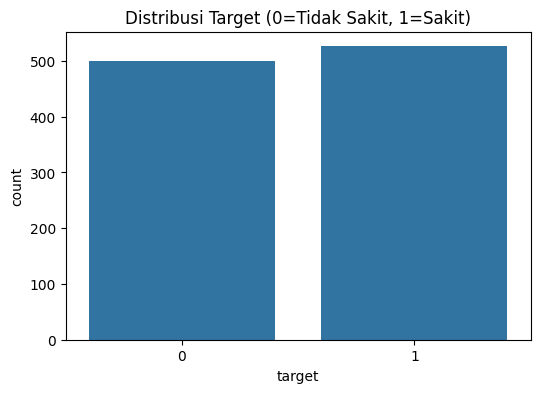

target
1    526
0    499
Name: count, dtype: int64


In [6]:
# 4.3 Distribusi target
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Distribusi Target (0=Tidak Sakit, 1=Sakit)')
plt.show()
print(df['target'].value_counts())

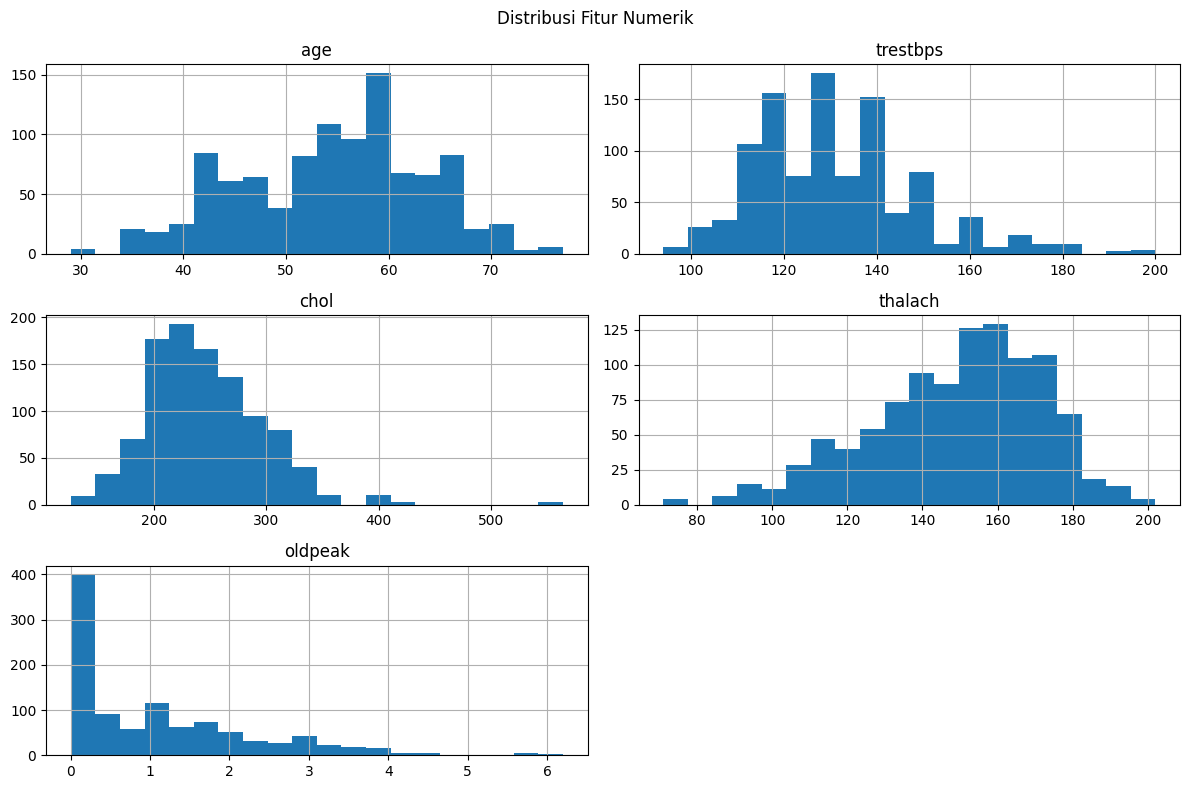

In [7]:
# 4.4 Distribusi fitur numerik
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[numerical_cols].hist(figsize=(12,8), bins=20)
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.show()

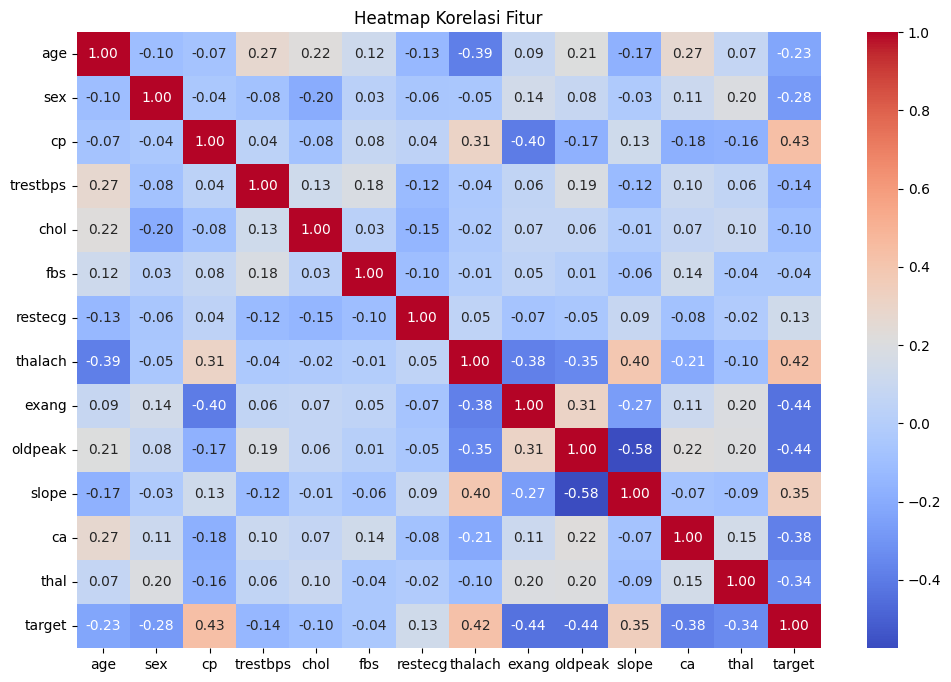

In [8]:
# 4.5 Korelasi heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur')
plt.show()

In [9]:
# 4.6 Identifikasi kolom kategorikal vs numerik
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
print("Kolom kategorikal:", categorical_cols)
print("Kolom numerik:", numerical_cols)

Kolom kategorikal: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Kolom numerik: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
# 5.1 Hapus duplikat (jika ada)
df_clean = df.drop_duplicates()
print("Shape setelah hapus duplikat:", df_clean.shape)

Shape setelah hapus duplikat: (302, 14)


In [11]:
# 5.2 Tangani missing values (dataset ini bersih, tapi tetap dicek)
df_clean = df_clean.dropna()
print("Shape setelah hapus missing values:", df_clean.shape)

Shape setelah hapus missing values: (302, 14)


In [12]:
# 5.3 Pisahkan fitur dan target
X = df_clean.drop('target', axis=1)
y = df_clean['target']

In [13]:
# 5.4 Normalisasi fitur numerik
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
print("Normalisasi selesai. Sample hasil:")
X[numerical_cols].head()

Normalisasi selesai. Sample hasil:


,age,trestbps,chol,thalach,oldpeak
0,-0.267966,-0.376556,-0.667728,0.806035,-0.037124
1,-0.157260,0.478910,-0.841918,0.237495,1.773958
2,1.724733,0.764066,-1.403197,-1.074521,1.342748
3,0.728383,0.935159,-0.841918,0.499898,-0.899544
4,0.839089,0.364848,0.919336,-1.905464,0.739054


In [14]:
# 5.5 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (241, 13)
Shape X_test: (61, 13)


In [15]:
# 5.6 Gabungkan kembali dan simpan hasil preprocessing
train_data = X_train.copy()
train_data['target'] = y_train.values
test_data = X_test.copy()
test_data['target'] = y_test.values

# Gabung untuk simpan sebagai satu file
df_preprocessed = pd.concat([train_data, test_data], ignore_index=True)
df_preprocessed.to_csv('heart_preprocessing.csv', index=False)
print("Dataset preprocessing berhasil disimpan!")
print("Shape final:", df_preprocessed.shape)
df_preprocessed.head()

Dataset preprocessing berhasil disimpan!
Shape final: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,1.392616,0,2,-0.946867,6.145034,0,0,0.456164,0,0.480328,1,0,3,1
1,-0.489377,1,0,0.707035,-0.899981,0,0,-1.030787,1,-0.123366,1,0,3,0
2,0.396267,1,0,-0.205463,-0.590310,0,0,-0.812118,1,0.997780,1,3,3,0
3,1.614027,1,2,0.478910,0.145158,0,0,-0.156110,0,0.825296,1,3,3,0
4,-1.042904,0,1,-1.117961,-1.674159,0,1,-0.505981,0,-0.899544,1,0,2,1
